In [333]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import statsmodels.api as sm

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

In [334]:
df = pd.read_csv('essays_features.csv')
print(f'Loaded {len(df):,} essays')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Loaded 17,307 essays
Columns: ['essay_id', 'full_text', 'score', 'clean_text', 'word_count', 'sentence_count', 'avg_sentence_length', 'char_count', 'word_diversity', 'avg_word_length', 'unique_word_count', 'long_word_count']


,essay_id,full_text,score,clean_text,word_count,sentence_count,avg_sentence_length,char_count,word_diversity,avg_word_length,unique_word_count,long_word_count
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live the thing...,498,13,38.307692,2677,0.487952,4.369478,243,78
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,332,21,15.809524,1669,0.487952,4.018072,162,42
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,550,24,22.916667,3077,0.438182,4.574545,241,103


In [335]:
df['word_count'].value_counts().sort_index()
df['word_count'].describe()

count    17307.000000
mean       368.348241
std        150.394776
min        150.000000
25%        253.000000
50%        345.000000
75%        452.000000
max       1656.000000
Name: word_count, dtype: float64

In [336]:
df[['score','word_count','avg_sentence_length','word_diversity']].corr()

## This correlation is finding that word count is heavily, positively correlated with score
## Therefore those with a high word count are more likely to get a higher score in the holistic method

,score,word_count,avg_sentence_length,word_diversity
score,1.000000,0.690035,-0.077793,-0.469929
word_count,0.690035,1.000000,0.025160,-0.600753
avg_sentence_length,-0.077793,0.025160,1.000000,-0.085736
word_diversity,-0.469929,-0.600753,-0.085736,1.000000


In [337]:
# Create a TF-IDF vectorizer to convert text into numerical features
# max_features=3000 limits the vocabulary to the 3000 most important words
# stop_words='english' removes common English words like "the", "and", etc.
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

# Fit the vectorizer on the text data and transform it into a TF-IDF matrix
# df['clean_text'] is the column containing preprocessed text
# X is a sparse matrix where rows = documents and columns = words
X = tfidf.fit_transform(df['clean_text'])

# Initialize KMeans clustering model
# n_clusters=8 means we want to group the documents into 8 clusters
# random_state=42 ensures results are reproducible
kmeans = KMeans(n_clusters=8, random_state=42)

# Fit the KMeans model on the TF-IDF matrix and assign each document a cluster label
# fit_predict both trains the model and returns cluster assignments (0 to 7)
df['cluster'] = kmeans.fit_predict(X)

In [338]:
cluster_stats = df.groupby('cluster')['score'].agg(['mean','std','count'])

In [339]:
print(cluster_stats)
df.groupby('cluster')[['word_count','score']].mean()

             mean       std  count
cluster                           
0        2.853728  0.987061   2092
1        2.469091  0.814857   1650
2        3.011811  1.148655   2032
3        3.256454  1.093232   1162
4        2.972938  1.069160   3067
5        3.220854  0.915752   3491
6        3.096643  1.060423   1966
7        2.506768  1.007465   1847


,word_count,score
cluster,,
0,330.199331,2.853728
1,289.088485,2.469091
2,400.584646,3.011811
3,371.300344,3.256454
4,353.449299,2.972938
5,393.514466,3.220854
6,450.418616,3.096643
7,334.856524,2.506768


In [340]:
##REALLY STRONG CORRELATION BETWEEN LENGTH AND SCORE IN THE HUMAN SCORING -- SHOULD TRY TO REDUCE THIS CORRELATION

In [341]:
import statsmodels.api as sm

# Select predictor (independent) variables from the dataset
# These features describe writing style:
# - word_count: total number of words in the essay
# - sentence_count: number of sentences
# - avg_sentence_length: average words per sentence
X = df[['word_count', 'sentence_count', 'avg_sentence_length']]

# Add a constant term (intercept) to the regression model
# This allows the model to learn a baseline score when all features are zero
X = sm.add_constant(X)

# Define the target (dependent) variable we want to predict
# This is the human-assigned essay score
y = df['score']

# Fit an Ordinary Least Squares (OLS) linear regression model
# This estimates how writing features relate to essay scores
model = sm.OLS(y, X).fit()

# Store residuals (errors) from the model
# Residual = actual score - predicted score
# This shows how much the model under/over-predicts each essay
df['score_residual'] = model.resid

In [342]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Create a TF-IDF vectorizer to convert text into numerical features
# max_features=3000 keeps the 3000 most important words
# stop_words='english' removes common words like "the", "and", etc.
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

# Transform cleaned text into a numerical TF-IDF matrix
# Each row = document, each column = word importance score
X_text = tfidf.fit_transform(df['clean_text'])

# Initialize KMeans clustering algorithm
# We want to group essays into 8 clusters based on text similarity
# random_state=42 ensures results are reproducible
kmeans = KMeans(n_clusters=8, random_state=42)

# Fit KMeans on the TF-IDF matrix and assign each essay to a cluster
# Each row gets a cluster label (0–7) based on similarity of word usage
df['cluster'] = kmeans.fit_predict(X_text)

In [343]:
df.groupby('cluster')[['word_count','score']].mean()

,word_count,score
cluster,,
0,330.199331,2.853728
1,289.088485,2.469091
2,400.584646,3.011811
3,371.300344,3.256454
4,353.449299,2.972938
5,393.514466,3.220854
6,450.418616,3.096643
7,334.856524,2.506768


In [344]:
cluster_stats = df.groupby('cluster')['score_residual'].agg(['mean','std','count'])
cluster_score = df.groupby('cluster')['score'].agg(['mean','std','count'])

In [345]:
print(cluster_stats)

             mean       std  count
cluster                           
0        0.074868  0.689823   2092
1       -0.125100  0.761847   1650
2       -0.088221  0.827343   2032
3        0.316211  0.665012   1162
4        0.105600  0.722880   3067
5        0.146174  0.615305   3491
6       -0.250454  0.844979   1966
7       -0.259966  0.741969   1847


In [346]:
print(cluster_score)

             mean       std  count
cluster                           
0        2.853728  0.987061   2092
1        2.469091  0.814857   1650
2        3.011811  1.148655   2032
3        3.256454  1.093232   1162
4        2.972938  1.069160   3067
5        3.220854  0.915752   3491
6        3.096643  1.060423   1966
7        2.506768  1.007465   1847


In [347]:
## Evaluation Sequences 

In [348]:
df_random = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [349]:
df_clustered = df.sort_values('cluster').reset_index(drop=True)

In [350]:
df_length_sorted = df.sort_values('word_count').reset_index(drop=True)

In [351]:
# Define the number of rows (essays) per window/group
# Each window will contain 100 consecutive observations
window_size = 100

# Loop through three different versions of the dataset:
# - df_random: randomly ordered essays
# - df_clustered: essays grouped by cluster (e.g., topic/style)
# - df_length_sorted: essays sorted by length
for d in [df_random, df_clustered, df_length_sorted]:
    
    # Create a new column 'window_id' that assigns each row to a window
    # d.index gives the row index (0, 1, 2, ...)
    # Integer division (//) groups every 100 rows into the same window:
    # rows 0–99   → window 0
    # rows 100–199 → window 1
    # rows 200–299 → window 2, etc.
    d['window_id'] = d.index // window_size

In [352]:
# Group the randomly ordered dataset by window_id
# Then compute summary statistics (mean and standard deviation)
# for the score residuals within each window
random_stats = df_random.groupby('window_id')['score_residual'].agg(['mean', 'std'])

# Do the same for the clustered dataset (essays grouped by similarity/topic)
# This helps analyze how residuals behave when similar essays are grouped together
clustered_stats = df_clustered.groupby('window_id')['score_residual'].agg(['mean', 'std'])

# Do the same for the length-sorted dataset (essays ordered by length)
# This allows us to see if essay length impacts residual patterns
length_stats = df_length_sorted.groupby('window_id')['score_residual'].agg(['mean', 'std'])

In [353]:
random_stats['mean'].std()

0.07896223217057594

In [354]:
clustered_stats['mean'].std()

0.1880258950843249

In [355]:
length_stats['mean'].std()

0.25816152171503925

In [356]:
# Create a new column 'rolling_mean' in the clustered dataframe
# This computes a rolling (moving) average of the score residuals

# rolling(200) defines a window of 200 consecutive rows (essays)
# .mean() calculates the average residual within each window

# This helps smooth out short-term fluctuations and reveals trends
# in how residuals behave across similar (clustered) essays

# Note: The first 199 rows will be NaN since there are not enough
# previous observations to fill the window
df_clustered['rolling_mean'] = df_clustered['score_residual'].rolling(200).mean()
df_clustered['rolling_mean'] = df_clustered['score_residual'].rolling(200).mean()

In [357]:
## Statistical Testing 

In [358]:
from scipy.stats import ks_2samp

ks_2samp(
    df_random['score_residual'],
    df_clustered['score_residual']
)

KstestResult(statistic=0.0, pvalue=1.0, statistic_location=-6.964351841253471, statistic_sign=1)

In [359]:
# Select additional text-based features that may explain variation in residuals
# - word_diversity: measure of vocabulary richness (e.g., unique words / total words)
# - avg_word_length: average number of characters per word
# - long_word_count: number of longer/complex words
features = df[['word_diversity', 'avg_word_length', 'long_word_count']]

# Add a constant (intercept) term to the feature matrix
# This allows the regression to estimate a baseline residual value
X = sm.add_constant(features)

# Define the target variable as the residuals from the previous model
# We are now trying to explain what drives the leftover variation (errors)
y = df['score_residual']

# Fit an Ordinary Least Squares (OLS) regression model
# This examines how these additional features relate to the residuals
model = sm.OLS(y, X).fit()

# Print a detailed summary of the regression results
# Includes coefficients, p-values, R-squared, and statistical significance
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         score_residual   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     367.3
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          2.67e-231
Time:                        22:51:15   Log-Likelihood:                -19035.
No. Observations:               17307   AIC:                         3.808e+04
Df Residuals:                   17303   BIC:                         3.811e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.1218      0.092    -

In [360]:
train = pd.read_csv("essays_features.csv")


In [361]:
from sklearn.model_selection import train_test_split

X = train["full_text"]
y = train["score"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT: keeps score distribution balanced
)

In [362]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

In [363]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial"
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=2000, multi_class='multinomial')

In [364]:
from sklearn.metrics import accuracy_score, cohen_kappa_score

val_preds = model.predict(X_val_tfidf)

print("Accuracy:", accuracy_score(y_val, val_preds))
print("QWK:", cohen_kappa_score(y_val, val_preds, weights="quadratic"))

Accuracy: 0.4858463316002311
QWK: 0.60044840251478


In [365]:
df = test.copy()
df["pred_score"] = test_preds

In [366]:
train["pred_score"] = model.predict(tfidf.transform(train["full_text"]))

In [367]:
train["score"].value_counts(normalize=True).sort_index()
train["pred_score"].value_counts(normalize=True).sort_index()

pred_score
1    0.036170
2    0.274629
3    0.466921
4    0.215404
5    0.006876
Name: proportion, dtype: float64

In [368]:
train[["score","word_count","word_diversity"]].corr()

,score,word_count,word_diversity
score,1.000000,0.690035,-0.469929
word_count,0.690035,1.000000,-0.600753
word_diversity,-0.469929,-0.600753,1.000000


In [369]:
train[["pred_score","word_count","word_diversity"]].corr()

,pred_score,word_count,word_diversity
pred_score,1.000000,0.570155,-0.354187
word_count,0.570155,1.000000,-0.600753
word_diversity,-0.354187,-0.600753,1.000000


In [370]:
train["cluster"] = kmeans.fit_predict(X_text)

In [371]:
train.groupby("cluster")[["score","pred_score"]].mean()

,score,pred_score
cluster,,
0,2.853728,2.734226
1,2.469091,2.335152
2,3.011811,2.935531
3,3.256454,3.133391
4,2.972938,2.868275
5,3.220854,3.220281
6,3.096643,3.081892
7,2.506768,2.493232


In [372]:
train["cluster"] = kmeans.fit_predict(X_text)

In [373]:
train.groupby("cluster")[["score","pred_score"]].mean()

,score,pred_score
cluster,,
0,2.853728,2.734226
1,2.469091,2.335152
2,3.011811,2.935531
3,3.256454,3.133391
4,2.972938,2.868275
5,3.220854,3.220281
6,3.096643,3.081892
7,2.506768,2.493232


In [374]:
train.groupby("cluster")[["score","pred_score"]].std()

,score,pred_score
cluster,,
0,0.987061,0.668420
1,0.814857,0.617935
2,1.148655,0.827445
3,1.093232,0.812438
4,1.069160,0.779044
5,0.915752,0.686673
6,1.060423,0.828812
7,1.007465,0.828679


In [375]:
df_sorted = train.sort_values("cluster").reset_index(drop=True)
df_sorted["window"] = df_sorted.index // 100

In [376]:
df_sorted.groupby("window")[["score","pred_score"]].mean()

,score,pred_score
window,,
0,2.630000,2.600000
1,2.850000,2.700000
2,2.850000,2.780000
3,2.840000,2.740000
4,2.770000,2.700000
...,...,...
169,2.470000,2.490000
170,2.390000,2.560000
171,2.580000,2.660000


In [377]:
human_drift = df_sorted.groupby("window")["score"].mean().std()
model_drift = df_sorted.groupby("window")["pred_score"].mean().std()

In [378]:
print(human_drift)
print(model_drift)

0.2804244895804696
0.29083771661448715


**RESULTS**

In [380]:
# Generate predicted scores for both train and test datasets
# These represent the model's estimate of the human score
train["pred_score"] = model.predict(tfidf.transform(train["full_text"]))
test["pred_score"] = model.predict(tfidf.transform(test["full_text"]))

# Label the source of each row for later comparison
train["dataset"] = "train"
test["dataset"] = "test"

# Test data does not have human scores, so we set it to None
test["score"] = None

# Combine into one dataset for unified analysis
final_df = pd.concat([train, test], ignore_index=True)

# Keep only relevant columns for analysis and visualization
final_df = final_df[[
    "essay_id",
    "dataset",
    "score",
    "pred_score",
    "word_count",
    "sentence_count",
    "avg_sentence_length",
    "word_diversity",
    "avg_word_length",
    "long_word_count"
]]

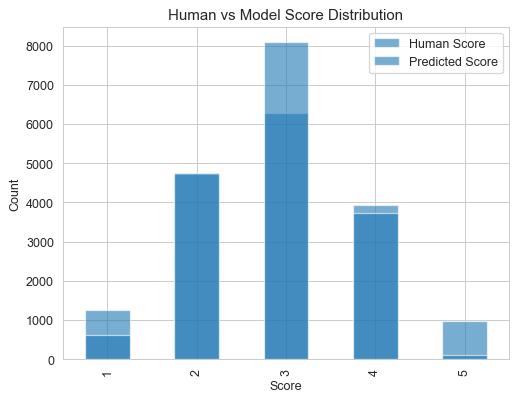

In [381]:
import matplotlib.pyplot as plt

plt.figure()

# Plot distribution of human scores
train["score"].value_counts().sort_index().plot(
    kind="bar", alpha=0.6, label="Human Score"
)

# Plot distribution of predicted scores
train["pred_score"].value_counts().sort_index().plot(
    kind="bar", alpha=0.6, label="Predicted Score"
)

plt.legend()
plt.title("Human vs Model Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

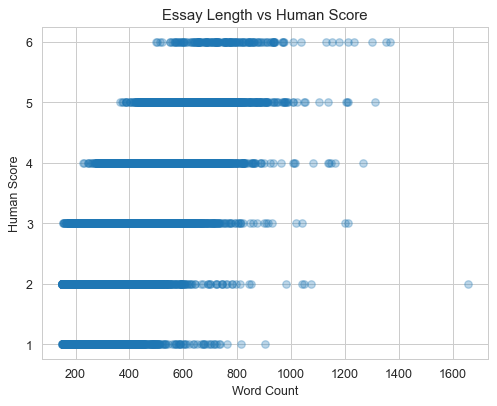

In [382]:
plt.figure()

plt.scatter(train["word_count"], train["score"], alpha=0.3)

plt.xlabel("Word Count")
plt.ylabel("Human Score")
plt.title("Essay Length vs Human Score")
plt.show()

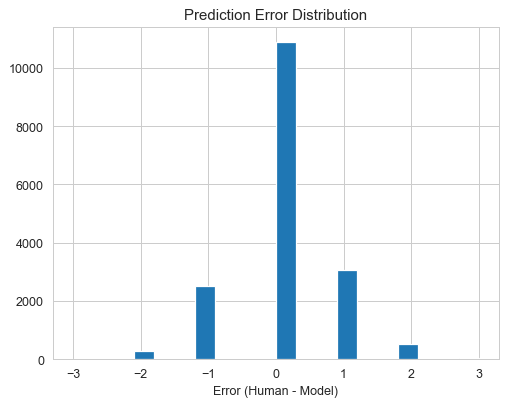

In [385]:
train["error"] = train["score"] - train["pred_score"]

plt.hist(train["error"], bins=20)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Human - Model)")
plt.show()

In [387]:
import numpy as np

feature_names = tfidf.get_feature_names_out()

coefs = model.coef_[0]

top_positive = np.argsort(coefs)[-20:]
top_negative = np.argsort(coefs)[:20]

print("Top positive words:", feature_names[top_positive])
print("Top negative words:", feature_names[top_negative])

Top positive words: ['lisa' 'sky' 'art' 'scientist' 'people cars' 'theres' 'district'
 'mona lisa' 'venus actually' 'plant' 'till' 'president state' 'mona'
 'star' 'thats' 'story' 'dont' 'stuff' 'sun' 'luke']
Top negative words: ['students' 'author' 'help' 'states' 'animals' 'idea' 'driverless'
 'technology' 'car' 'student' 'landform' 'seagoing' 'reasons' 'pollution'
 'does' 'cars' 'join' 'just' 'usage' 'electoral college']
